In [41]:
import numpy as np


def generate_fcc_lattice ( n_cells , rho_star ):

    """
    Generates an FCC lattice of atoms .
    TASK :
    1. Calculate the box length L based on density (rho = N/V).
    2. Place 4 atoms in each of the n_cells ^3 unit cells .
    """
    L = (4 * n_cells ** 3 / rho_star) ** (1 / 3)
    a = L / n_cells 
    b1 = np.array([0, 0, 0])
    b2 = np.array([a / 2, a / 2, 0])
    b3 = np.array([a / 2, 0, a / 2])
    b4 = np.array([0, a / 2, a / 2])
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * (L / n_cells)
                positions.append(cell_origin + b1)
                positions.append(cell_origin + b2)
                positions.append(cell_origin + b3)
                positions.append(cell_origin + b4)

    return np.array(positions), L


# YOUR CODE HERE
def apply_minimum_image (pos_i , pos_j , L):
    """
    Calculates the shortest distance vector between two atoms .
    TASK : Use the rounding logic to ensure dx ,
    dy , and dz
    are between -L/2 and L/2.
    """
    dr = pos_j - pos_i
    dr -= L * np.round(dr / L)
    return dr

Positions of atoms in the FCC lattice:
Box length L: 2.0


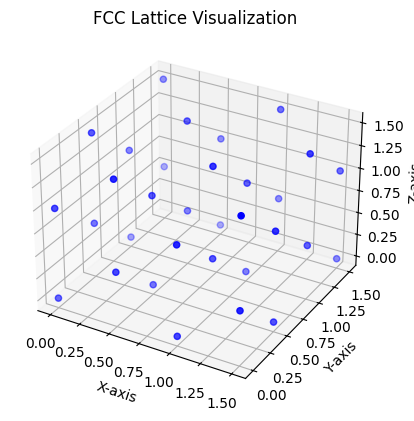

In [42]:
#visualize lattice
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n = 2
rho_star = 4
positions, L = generate_fcc_lattice(n, rho_star)
print("Positions of atoms in the FCC lattice:")
# print(positions)
print("Box length L:", L)


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c='b', marker='o')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('FCC Lattice Visualization')
plt.show()

In [60]:
L = 2
pos_i = np.array([0.5, 7, 10])
pos_j = np.array([1.6, 118, 105])
dr = apply_minimum_image(pos_i, pos_j, L)
print("Shortest distance vector between pos_i and pos_j:", dr)
mod_dr = np.linalg.norm(dr,ord = 2)
print(mod_dr)

Shortest distance vector between pos_i and pos_j: [-0.9 -1.  -1. ]
1.676305461424021
